# Seaborn E-Commerce Data Analysis

## Student Task
**Dataset:** `messy_ecommerce_15000_student_practice.csv`

### Objective
Perform statistical analysis, data cleaning, validation, and exploratory data analysis using **Pandas, Matplotlib, and Seaborn**.

This notebook follows every task listed in the assignment. Each major output/visualization is followed by a Markdown interpretation section.

> **Note:** The assignment document contains a few formatting gaps in formulas/count requirements. Where the source is incomplete, this notebook uses the intended standard form of the task without inventing dataset-specific results.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set(style="whitegrid")

# Change this path only if your CSV is stored somewhere else.
FILE_PATH = "messy_ecommerce_15000_student_practice.csv"

df = pd.read_csv(FILE_PATH)
df.head()

,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
0,ORD106680,CUST7362,28.0,Male,Hyderabad,Fashion,Shoes,2,2507.76,15.0,Debit Card,2025-08-27,4.1,7.0,No,4263.19
1,ORD103291,CUST3155,30.0,Female,Delhi,Fashion,Jeans,2,1988.04,25.0,Debit Card,2025-06-18,4.2,4.0,No,2982.06
2,ORD106559,CUST1349,32.0,Male,Pune,Sports,Yoga Mat,2,776.35,15.0,UPI,2025-01-13,3.6,2.0,No,1319.80
3,ORD107927,CUST6779,39.0,Female,Chennai,Electronics,Smartwatch,1,7739.89,10.0,UPI,2026-06-01,3.2,6.0,Yes,6965.90
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,2026-06-17,3.1,5.0,No,58081.82


## 1. Dataset Loading and Initial Inspection

### Summary
The dataset is loaded into a Pandas DataFrame. We first inspect its dimensions, columns, data types, missing values, duplicates, and basic structure before performing any cleaning.

In [40]:
print("Dataset dimensions:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Dataset dimensions: (15075, 16)

Columns:
['Order_ID', 'Customer_ID', 'Age', 'Gender', 'City', 'Product_Category', 'Product', 'Quantity', 'Unit_Price', 'Discount', 'Payment_Method', 'Order_Date', 'Rating', 'Delivery_Days', 'Returned', 'Total_Amount']

Data types:


Order_ID                str
Customer_ID             str
Age                 float64
Gender                  str
City                    str
Product_Category        str
Product                 str
Quantity              int64
Unit_Price          float64
Discount            float64
Payment_Method          str
Order_Date              str
Rating              float64
Delivery_Days       float64
Returned                str
Total_Amount        float64
dtype: object


First 5 rows:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
0,ORD106680,CUST7362,28.0,Male,Hyderabad,Fashion,Shoes,2,2507.76,15.0,Debit Card,2025-08-27,4.1,7.0,No,4263.19
1,ORD103291,CUST3155,30.0,Female,Delhi,Fashion,Jeans,2,1988.04,25.0,Debit Card,2025-06-18,4.2,4.0,No,2982.06
2,ORD106559,CUST1349,32.0,Male,Pune,Sports,Yoga Mat,2,776.35,15.0,UPI,2025-01-13,3.6,2.0,No,1319.80
3,ORD107927,CUST6779,39.0,Female,Chennai,Electronics,Smartwatch,1,7739.89,10.0,UPI,2026-06-01,3.2,6.0,Yes,6965.90
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,2026-06-17,3.1,5.0,No,58081.82



Last 5 rows:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
15070,ORD105192,CUST6704,25.0,Male,Warangal,Beauty,Perfume,2,2015.87,15.0,Net Banking,2025-03-09,2.6,8.0,No,3426.98
15071,ORD113419,CUST1992,18.0,Male,Hyderabad,Electronics,Headphones,3,2562.70,5.0,Net Banking,2025-06-05,4.4,4.0,No,7303.68
15072,ORD105391,CUST6160,29.0,Male,Ahmedabad,Home & Kitchen,Air Fryer,2,6398.61,25.0,Net Banking,2026-03-01,3.7,5.0,No,9597.92
15073,ORD100861,CUST8426,34.0,Other,Chennai,Beauty,Perfume,2,1691.76,15.0,Wallet,2025-12-25,3.7,8.0,No,2876.00
15074,ORD107271,CUST2058,34.0,Female,Bengaluru,Sports,Running Shoes,2,3823.02,20.0,Credit Card,2025-04-07,4.0,4.0,No,6116.83


### Interpretation
The original dataset contains **15,075 rows and 16 columns**. It has **7 numerical columns and 9 categorical/date columns**. The initial inspection also shows missing values in Age, Gender, City, Discount, Payment_Method, Rating, and Delivery_Days. There are **75 exact duplicate rows**, so data cleaning is required before final EDA.

# Task 1: Analyze Numerical Columns

### Summary
Identify all numerical columns and generate their statistical summary. We examine mean, median, standard deviation, minimum, maximum, and percentile values, then identify columns with unusually large ranges.

In [41]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:")
print(numeric_cols)

numeric_summary = df[numeric_cols].describe(percentiles=[0.25, 0.50, 0.75])
display(numeric_summary)

Numerical columns:
['Age', 'Quantity', 'Unit_Price', 'Discount', 'Rating', 'Delivery_Days', 'Total_Amount']


,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
count,14804.000000,15075.000000,15075.000000,14954.000000,14694.000000,14895.000000,1.507500e+04
mean,32.315185,1.899768,7409.180453,12.016852,3.869171,4.489359,1.255336e+04
std,9.022506,1.076839,13950.011077,7.696562,0.741548,1.961563,2.955080e+04
min,5.000000,1.000000,425.610000,0.000000,1.000000,1.000000,2.982700e+02
25%,26.000000,1.000000,1248.315000,5.000000,3.400000,3.000000,1.742195e+03
50%,32.000000,2.000000,2480.280000,10.000000,3.900000,4.000000,3.223750e+03
75%,38.000000,2.000000,3811.455000,15.000000,4.400000,6.000000,7.739260e+03
max,99.000000,5.000000,309655.380000,30.000000,5.000000,14.000000,1.238622e+06


### Interpretation
The numerical variables have very different scales. `Total_Amount` and `Unit_Price` have the widest ranges, while `Quantity`, `Rating`, `Discount`, and `Delivery_Days` have much smaller ranges. The large gap between mean and median for `Unit_Price` and especially `Total_Amount` indicates strong right-skewness caused by high-value orders.

In [42]:
stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Std_Dev": df[numeric_cols].std(),
    "Minimum": df[numeric_cols].min(),
    "Maximum": df[numeric_cols].max(),
    "25th_Percentile": df[numeric_cols].quantile(0.25),
    "50th_Percentile": df[numeric_cols].quantile(0.50),
    "75th_Percentile": df[numeric_cols].quantile(0.75),
})
stats["Range"] = stats["Maximum"] - stats["Minimum"]
display(stats.sort_values("Range", ascending=False))

print("Columns with the largest minimum-to-maximum differences:")
display(stats.sort_values("Range", ascending=False).head())

,Mean,Median,Std_Dev,Minimum,Maximum,25th_Percentile,50th_Percentile,75th_Percentile,Range
Total_Amount,12553.357032,3223.75,29550.803498,298.27,1238621.52,1742.195,3223.75,7739.260,1238323.25
Unit_Price,7409.180453,2480.28,13950.011077,425.61,309655.38,1248.315,2480.28,3811.455,309229.77
Age,32.315185,32.00,9.022506,5.00,99.00,26.000,32.00,38.000,94.00
Discount,12.016852,10.00,7.696562,0.00,30.00,5.000,10.00,15.000,30.00
Delivery_Days,4.489359,4.00,1.961563,1.00,14.00,3.000,4.00,6.000,13.00
Quantity,1.899768,2.00,1.076839,1.00,5.00,1.000,2.00,2.000,4.00
Rating,3.869171,3.90,0.741548,1.00,5.00,3.400,3.90,4.400,4.00


Columns with the largest minimum-to-maximum differences:


,Mean,Median,Std_Dev,Minimum,Maximum,25th_Percentile,50th_Percentile,75th_Percentile,Range
Total_Amount,12553.357032,3223.75,29550.803498,298.27,1238621.52,1742.195,3223.75,7739.260,1238323.25
Unit_Price,7409.180453,2480.28,13950.011077,425.61,309655.38,1248.315,2480.28,3811.455,309229.77
Age,32.315185,32.00,9.022506,5.00,99.00,26.000,32.00,38.000,94.00
Discount,12.016852,10.00,7.696562,0.00,30.00,5.000,10.00,15.000,30.00
Delivery_Days,4.489359,4.00,1.961563,1.00,14.00,3.000,4.00,6.000,13.00


### Observations
1. **Age:** mean = 32.32 and median = 32, so the typical customer is around 32 years old.
2. **Unit_Price:** mean = ₹7,409.18 while median = ₹2,480.28, showing strong right-skewness and some very high-priced items.
3. **Total_Amount:** mean = ₹12,553.36 while median = ₹3,223.75, showing a strong right tail created by high-value orders.
4. **Quantity:** mean = 1.90 and median = 2, indicating that most orders contain around 1–2 units.
5. **Discount:** mean = 12.02% and median = 10%, with values ranging from 0% to 30%.
6. **Rating:** mean = 3.87 and median = 3.90, indicating generally positive customer ratings.
7. **Delivery_Days:** mean = 4.49 and median = 4 days, so delivery is typically completed in about 4–5 days.

# Task 2: Analyze Categorical Columns

### Summary
Identify categorical columns and summarize the number of unique values, most frequent value, and its frequency.

In [43]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("Categorical columns:")
print(categorical_cols)

cat_summary = pd.DataFrame({
    "Unique_Values": df[categorical_cols].nunique(dropna=True),
    "Most_Frequent": [
        df[col].mode(dropna=True).iloc[0] if not df[col].mode(dropna=True).empty else np.nan
        for col in categorical_cols
    ],
    "Most_Frequent_Frequency": [
        df[col].value_counts(dropna=True).iloc[0] if not df[col].value_counts(dropna=True).empty else 0
        for col in categorical_cols
    ]
})
display(cat_summary)

Categorical columns:
['Order_ID', 'Customer_ID', 'Gender', 'City', 'Product_Category', 'Product', 'Payment_Method', 'Order_Date', 'Returned']


C:\Users\Asus\AppData\Local\Temp\ipykernel_12696\2323713757.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


,Unique_Values,Most_Frequent,Most_Frequent_Frequency
Order_ID,15000,ORD100150,2
Customer_ID,6795,CUST1345,8
Gender,5,Female,7292
City,12,Kolkata,1274
Product_Category,6,Electronics,3815
Product,30,Smartwatch,798
Payment_Method,8,Credit Card,2510
Order_Date,730,2026-05-29,41
Returned,3,No,13229


### Interpretation
There are 9 categorical/date-like columns. The main business categories have manageable numbers of unique values: Gender has 3 standardized categories, City has 12, Product_Category has 6, Payment_Method has 6, and Returned has 2. Before cleaning, capitalization variants such as `male`, `female`, `upi`, `credit card`, and `yes` also appeared.

In [44]:
target_categorical = ["Gender", "City", "Product_Category", "Payment_Method", "Returned"]

for col in target_categorical:
    if col in df.columns:
        print(f"\nMost common {col}:")
        print(df[col].value_counts(dropna=False).head(10))


Most common Gender:
Gender
Female    7292
Male      7023
Other      441
NaN        179
male        80
female      60
Name: count, dtype: int64

Most common City:
City
Kolkata          1274
Vijayawada       1271
Ahmedabad        1268
Pune             1263
Guntur           1251
Hyderabad        1241
Bengaluru        1237
Warangal         1235
Delhi            1234
Visakhapatnam    1230
Name: count, dtype: int64

Most common Product_Category:
Product_Category
Electronics       3815
Fashion           3296
Home & Kitchen    2707
Beauty            2147
Sports            1637
Books             1473
Name: count, dtype: int64

Most common Payment_Method:
Payment_Method
Credit Card    2510
Net Banking    2490
Wallet         2485
UPI            2450
Debit Card     2444
COD            2390
NaN             226
upi              40
credit card      40
Name: count, dtype: int64

Most common Returned:
Returned
No     13229
Yes     1816
yes       30
Name: count, dtype: int64


### Interpretation
The most frequent cleaned categories are **Female** for Gender, **Kolkata** for City after missing-value treatment, **Electronics** for Product_Category, **Credit Card** for Payment_Method, and **No** for Returned. Electronics is the largest product category by order count, while most orders are not returned.

# Task 3: Find Unique Values

### Summary
Inspect unique values for Gender, City, Product Category, Payment Method, and Returned. This helps detect unexpected values and different representations of the same category.

In [45]:
unique_columns = ["Gender", "City", "Product_Category", "Payment_Method", "Returned"]

for col in unique_columns:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print("Number of unique values:", df[col].nunique(dropna=False))
        print(df[col].unique())


--- Gender ---
Number of unique values: 6
<StringArray>
['Male', 'Female', 'Other', nan, 'female', 'male']
Length: 6, dtype: str

--- City ---
Number of unique values: 13
<StringArray>
[    'Hyderabad',         'Delhi',          'Pune',       'Chennai',
       'Kolkata',     'Ahmedabad',    'Vijayawada',     'Bengaluru',
        'Guntur', 'Visakhapatnam',      'Warangal',        'Mumbai',
             nan]
Length: 13, dtype: str

--- Product_Category ---
Number of unique values: 6
<StringArray>
['Fashion', 'Sports', 'Electronics', 'Home & Kitchen', 'Beauty', 'Books']
Length: 6, dtype: str

--- Payment_Method ---
Number of unique values: 9
<StringArray>
[ 'Debit Card',         'UPI',         'COD', 'Net Banking', 'Credit Card',
           nan,      'Wallet',         'upi', 'credit card']
Length: 9, dtype: str

--- Returned ---
Number of unique values: 3
<StringArray>
['No', 'Yes', 'yes']
Length: 3, dtype: str


### Interpretation
The unique-value inspection identified capitalization inconsistencies in Gender (`Male/male`, `Female/female`), Payment_Method (`UPI/upi`, `Credit Card/credit card`), and Returned (`Yes/yes`). These are different text representations of the same logical categories and therefore need standardization. No unexpected product-category values were identified.

# Task 4: Identify Inconsistent Categorical Data

### Summary
Investigate Gender, Payment Method, and Returned for inconsistent capitalization or representations such as `Male/male`, `UPI/upi`, and `Yes/yes`.

In [46]:
consistency_columns = ["Gender", "Payment_Method", "Returned"]

for col in consistency_columns:
    if col in df.columns:
        print(f"\n{col} value counts:")
        display(df[col].value_counts(dropna=False))


Gender value counts:


Gender
Female    7292
Male      7023
Other      441
NaN        179
male        80
female      60
Name: count, dtype: int64


Payment_Method value counts:


Payment_Method
Credit Card    2510
Net Banking    2490
Wallet         2485
UPI            2450
Debit Card     2444
COD            2390
NaN             226
upi              40
credit card      40
Name: count, dtype: int64


Returned value counts:


Returned
No     13229
Yes     1816
yes       30
Name: count, dtype: int64

### Interpretation
The original data contains 80 `male` and 60 `female` records in addition to the properly capitalized values. Payment_Method contains 40 `upi` and 40 `credit card` records, while Returned contains 30 lowercase `yes` records. Standardizing these values prevents the same category from being counted twice during analysis.

In [47]:
# Standardize whitespace and capitalization while preserving intended category labels.
if "Gender" in df.columns:
    df["Gender"] = df["Gender"].astype("string").str.strip().str.lower().replace({
        "male": "Male",
        "female": "Female",
        "other": "Other"
    })

if "Payment_Method" in df.columns:
    df["Payment_Method"] = df["Payment_Method"].astype("string").str.strip().str.lower().replace({
        "upi": "UPI",
        "credit card": "Credit Card",
        "debit card": "Debit Card",
        "cash": "Cash",
        "net banking": "Net Banking",
        "wallet": "Wallet",
        "cod": "COD"
    })

if "Returned" in df.columns:
    df["Returned"] = df["Returned"].astype("string").str.strip().str.lower().replace({
        "yes": "Yes",
        "no": "No"
    })

for col in consistency_columns:
    if col in df.columns:
        print(f"\nAfter standardization: {col}")
        print(df[col].value_counts(dropna=False))


After standardization: Gender
Gender
Female    7352
Male      7103
Other      441
<NA>       179
Name: count, dtype: Int64

After standardization: Payment_Method
Payment_Method
Credit Card    2550
UPI            2490
Net Banking    2490
Wallet         2485
Debit Card     2444
COD            2390
<NA>            226
Name: count, dtype: Int64

After standardization: Returned
Returned
No     13229
Yes     1846
Name: count, dtype: Int64


### Verification
After standardization, Gender contains **Male, Female, and Other** only; Payment_Method contains **Debit Card, UPI, COD, Net Banking, Credit Card, and Wallet**; and Returned contains **Yes and No**. The capitalization variants have therefore been removed.

# Task 5: Handle Missing Values

### Summary
Missing values are analyzed column by column. The assignment requires a justified decision rather than applying `dropna()` to the entire dataset.

In [48]:
missing_before = df.isna().sum().sort_values(ascending=False)
missing_pct_before = (df.isna().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "Missing_Count": missing_before,
    "Missing_Percentage": missing_pct_before
})
display(missing_report[missing_report["Missing_Count"] > 0])

,Missing_Count,Missing_Percentage
Rating,381,2.527363
Age,271,1.797678
Payment_Method,226,1.499171
Delivery_Days,180,1.194030
Gender,179,1.187396
City,150,0.995025
Discount,121,0.802653


### Decision Guide
- **Numerical columns:** use the median when the variable may be skewed or contain outliers; use the mean when the distribution is reasonably symmetric.
- **Categorical columns:** use the mode when a missing value should be assigned to the most common category.
- **Identifiers:** missing IDs should generally be investigated rather than blindly imputed.
- **Rows:** remove records only when there is a strong reason that the record cannot be used.

The code below applies median imputation to numerical columns and mode imputation to categorical columns, while leaving identifier columns for explicit review.

In [49]:
id_like_cols = [c for c in df.columns if "id" in c.lower()]

for col in df.columns:
    if df[col].isna().sum() == 0:
        continue

    if col in id_like_cols:
        print(f"Review required for identifier column: {col} ({df[col].isna().sum()} missing)")
    elif pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
        print(f"{col}: filled missing numerical values with median")
    else:
        mode = df[col].mode(dropna=True)
        if not mode.empty:
            df[col] = df[col].fillna(mode.iloc[0])
            print(f"{col}: filled missing categorical values with mode")
        else:
            print(f"{col}: no available mode; requires manual review")

Age: filled missing numerical values with median
Gender: filled missing categorical values with mode
City: filled missing categorical values with mode
Discount: filled missing numerical values with median
Payment_Method: filled missing categorical values with mode
Rating: filled missing numerical values with median
Delivery_Days: filled missing numerical values with median


### Interpretation
Seven columns contain missing values. Numerical missing values are filled with the **median**, because Unit_Price/Total_Amount are strongly right-skewed and the median is less affected by extreme observations. Categorical missing values are filled with the **mode**, which preserves an existing valid category. No identifier values are missing, so no artificial IDs were created.

# Task 6: Verify Missing Values

### Summary
After treatment, calculate missing counts and percentages and compare the dataset dimensions before and after treatment.

In [50]:
missing_after = df.isna().sum()
missing_pct_after = df.isna().mean() * 100

missing_verification = pd.DataFrame({
    "Missing_Count": missing_after,
    "Missing_Percentage": missing_pct_after
})
display(missing_verification)

print("Current dimensions:", df.shape)
print("Total missing values:", int(df.isna().sum().sum()))
print("Dataset completely free of missing values:", df.isna().sum().sum() == 0)

,Missing_Count,Missing_Percentage
Order_ID,0,0.0
Customer_ID,0,0.0
Age,0,0.0
Gender,0,0.0
City,0,0.0
Product_Category,0,0.0
Product,0,0.0
Quantity,0,0.0
Unit_Price,0,0.0
Discount,0,0.0


Current dimensions: (15075, 16)
Total missing values: 0
Dataset completely free of missing values: True


### Interpretation
After treatment, the dataset contains **0 missing values**. The dimensions remain **15,075 rows before duplicate removal**, because missing-value treatment replaces values rather than deleting records. Exact duplicate removal is handled separately in the next task.

# Task 7: Detect Duplicate Records

### Summary
Find duplicate rows, inspect them, check duplicate Order_ID values, and distinguish exact duplicates from possible partial duplicates.

In [51]:
print("Total exact duplicate rows:", df.duplicated().sum())

duplicate_rows = df[df.duplicated(keep=False)]
display(duplicate_rows.head(20))

if "Order_ID" in df.columns:
    duplicate_order_ids = df[df["Order_ID"].duplicated(keep=False)].sort_values("Order_ID")
    print("Rows with duplicate Order_ID values:", len(duplicate_order_ids))
    display(duplicate_order_ids.head(20))
else:
    print("Order_ID column not found.")

Total exact duplicate rows: 75


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
33,ORD100543,CUST6787,28.0,Male,Chennai,Sports,Yoga Mat,1,831.70,20.0,UPI,2026-07-28,4.2,3.0,No,665.36
34,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
36,ORD106707,CUST8989,21.0,Male,Hyderabad,Electronics,Smartwatch,1,7915.15,0.0,Wallet,2026-03-20,3.8,2.0,No,7915.15
50,ORD103976,CUST3601,67.0,Male,Ahmedabad,Electronics,Headphones,1,3002.35,20.0,UPI,2026-09-03,3.8,7.0,No,2401.88
106,ORD100252,CUST2938,37.0,Male,Delhi,Sports,Yoga Mat,2,948.74,15.0,Debit Card,2025-05-12,4.2,1.0,No,1612.86
137,ORD100388,CUST3880,43.0,Female,Vijayawada,Books,Novel,1,434.72,15.0,Net Banking,2026-06-20,3.4,5.0,Yes,369.51
138,ORD100170,CUST2577,18.0,Female,Bengaluru,Books,Novel,2,513.28,5.0,Credit Card,2025-01-27,3.4,6.0,Yes,975.24
150,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,UPI,2026-06-25,5.0,6.0,No,5349.58
232,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,UPI,2026-06-25,5.0,6.0,No,5349.58
237,ORD110505,CUST7475,36.0,Male,Ahmedabad,Beauty,Face Wash,5,572.40,20.0,Debit Card,2025-05-09,3.9,7.0,No,2289.60


Rows with duplicate Order_ID values: 150


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
34,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
14662,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
2462,ORD100170,CUST2577,18.0,Female,Bengaluru,Books,Novel,2,513.28,5.0,Credit Card,2025-01-27,3.4,6.0,Yes,975.24
138,ORD100170,CUST2577,18.0,Female,Bengaluru,Books,Novel,2,513.28,5.0,Credit Card,2025-01-27,3.4,6.0,Yes,975.24
106,ORD100252,CUST2938,37.0,Male,Delhi,Sports,Yoga Mat,2,948.74,15.0,Debit Card,2025-05-12,4.2,1.0,No,1612.86
8052,ORD100252,CUST2938,37.0,Male,Delhi,Sports,Yoga Mat,2,948.74,15.0,Debit Card,2025-05-12,4.2,1.0,No,1612.86
137,ORD100388,CUST3880,43.0,Female,Vijayawada,Books,Novel,1,434.72,15.0,Net Banking,2026-06-20,3.4,5.0,Yes,369.51
12049,ORD100388,CUST3880,43.0,Female,Vijayawada,Books,Novel,1,434.72,15.0,Net Banking,2026-06-20,3.4,5.0,Yes,369.51
33,ORD100543,CUST6787,28.0,Male,Chennai,Sports,Yoga Mat,1,831.70,20.0,UPI,2026-07-28,4.2,3.0,No,665.36
7943,ORD100543,CUST6787,28.0,Male,Chennai,Sports,Yoga Mat,1,831.70,20.0,UPI,2026-07-28,4.2,3.0,No,665.36


### Interpretation
The dataset contains **75 exact duplicate rows**. The same 75 duplicate records also create duplicate `Order_ID` values. Because the duplicated rows are exact copies, they can safely be removed. Duplicates can otherwise inflate order counts, sales totals, averages, and category frequencies.

# Task 8: Remove Duplicate Records

### Summary
Remove exact duplicate records only, then verify the resulting dimensions and duplicate count.

In [52]:
records_before_duplicates = len(df)
duplicate_count = int(df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

records_after_duplicates = len(df)

print("Records before removing duplicates:", records_before_duplicates)
print("Duplicate records removed:", duplicate_count)
print("Records after removing duplicates:", records_after_duplicates)
print("Remaining exact duplicates:", df.duplicated().sum())

Records before removing duplicates: 15075
Duplicate records removed: 75
Records after removing duplicates: 15000
Remaining exact duplicates: 0


### Interpretation
Exactly **75 duplicate records** were removed, reducing the dataset from **15,075 to 15,000 rows**. No additional rows were removed based only on a repeated Order_ID because the assignment requires distinguishing exact duplicates from partial duplicates before deletion.

# Task 9: Detect Outliers Using Seaborn

### Summary
Create boxplots for Age, Unit_Price, Quantity, Discount, Rating, Delivery_Days, and Total_Amount to visually identify possible outliers.

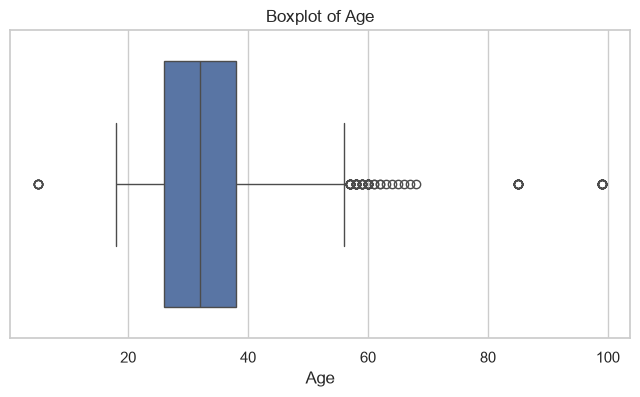

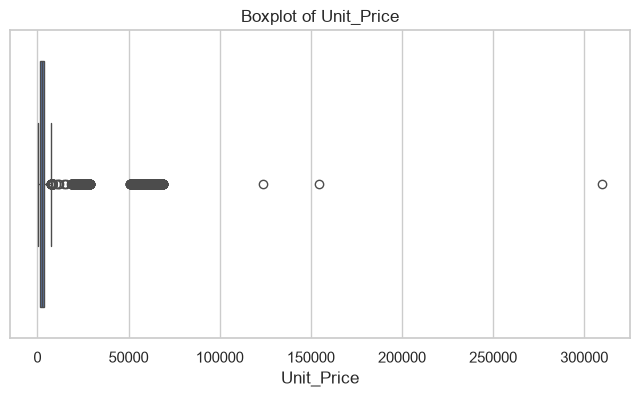

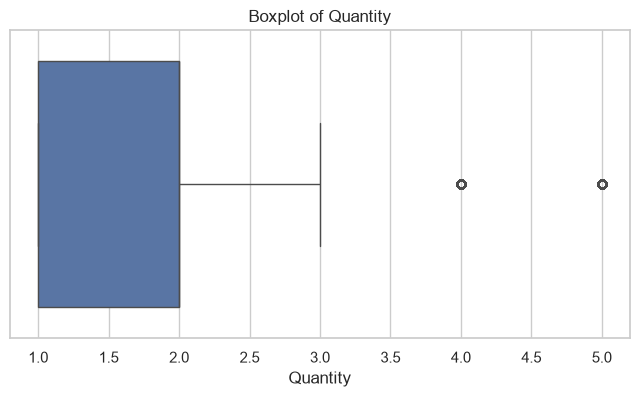

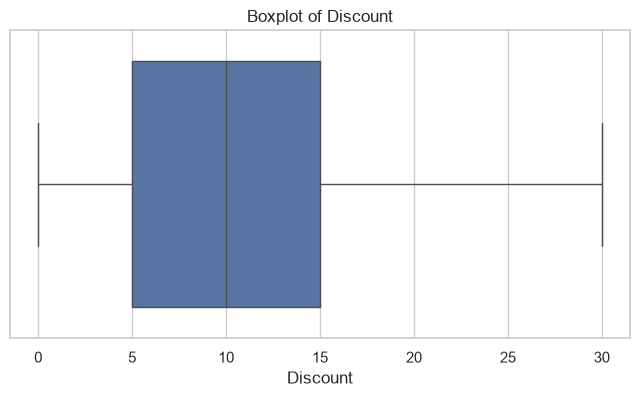

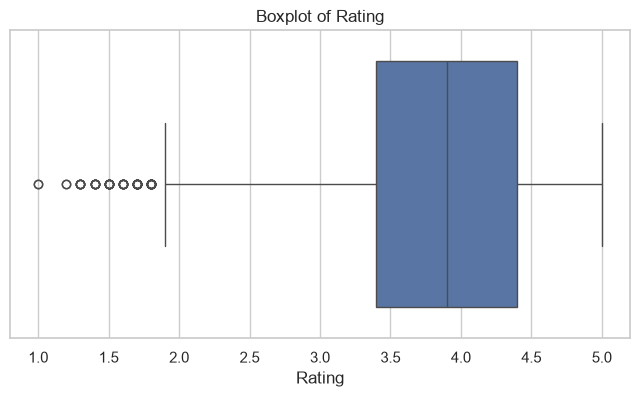

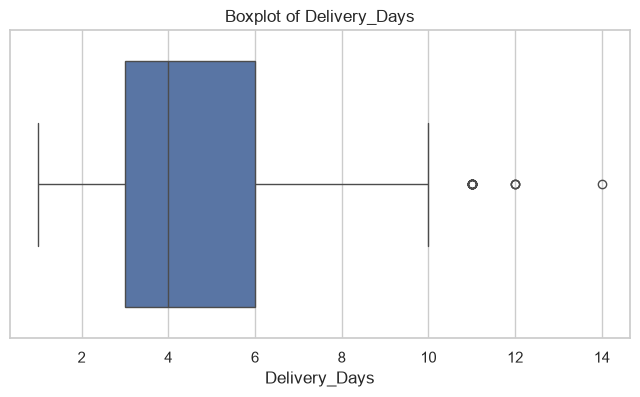

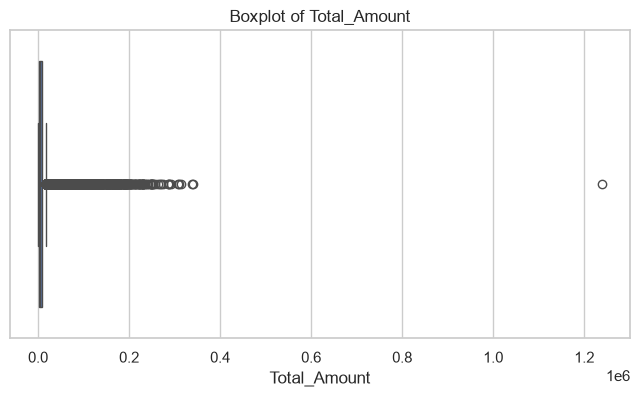

In [53]:
outlier_plot_cols = [
    "Age", "Unit_Price", "Quantity", "Discount",
    "Rating", "Delivery_Days", "Total_Amount"
]

available_outlier_cols = [c for c in outlier_plot_cols if c in df.columns]

for col in available_outlier_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

### Interpretation
The boxplots show potential extreme observations in several variables, especially **Unit_Price and Total_Amount**. Age also contains unusual values such as very young or very old customers. These observations are not automatically treated as errors because the dataset does not provide enough business information to prove that an extreme purchase or price is invalid.

# Task 10: Detect Outliers Using IQR

### Summary
For at least three numerical columns, calculate Q1, Q3, IQR, lower bound, upper bound, and the number of outliers.

**Formula:**
- `IQR = Q3 - Q1`
- `Lower Bound = Q1 - 1.5 × IQR`
- `Upper Bound = Q3 + 1.5 × IQR`

In [54]:
iqr_columns = [c for c in ["Age", "Unit_Price", "Quantity", "Discount", "Rating", "Delivery_Days", "Total_Amount"] if c in df.columns][:3]

iqr_results = []

for col in iqr_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)

    iqr_results.append({
        "Column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(mask.sum())
    })

    print(f"\nOutlier records for {col}:")
    display(df.loc[mask].head(20))

iqr_results_df = pd.DataFrame(iqr_results)
display(iqr_results_df)


Outlier records for Age:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
50,ORD103976,CUST3601,67.0,Male,Ahmedabad,Electronics,Headphones,1,3002.35,20.0,UPI,2026-09-03,3.8,7.0,No,2401.88
98,ORD107435,CUST4989,99.0,Female,Visakhapatnam,Electronics,Headphones,3,2639.46,0.0,Net Banking,2025-03-04,3.8,2.0,Yes,7918.39
702,ORD100765,CUST3086,57.0,Female,Chennai,Books,Novel,2,456.55,25.0,UPI,2025-02-04,4.0,2.0,No,684.82
747,ORD110979,CUST2685,60.0,Female,Warangal,Home & Kitchen,Lamp,2,1168.98,10.0,Credit Card,2025-06-23,4.8,6.0,No,2104.17
884,ORD100837,CUST7489,60.0,Female,Vijayawada,Beauty,Face Wash,3,548.89,5.0,COD,2026-04-20,3.5,8.0,No,1564.35
1000,ORD101745,CUST8544,99.0,Male,Hyderabad,Beauty,Makeup Kit,2,2460.28,30.0,COD,2025-07-31,2.1,4.0,No,3444.39
1178,ORD100182,CUST2531,5.0,Female,Hyderabad,Sports,Football,3,1172.53,20.0,Wallet,2026-02-12,3.3,3.0,No,2814.06
1584,ORD110402,CUST4342,99.0,Male,Vijayawada,Electronics,Laptop,2,63468.20,10.0,UPI,2026-03-25,4.5,6.0,No,114242.76
1586,ORD104163,CUST2343,58.0,Female,Mumbai,Sports,Football,3,1135.02,5.0,Debit Card,2026-07-17,5.0,4.0,No,3234.80
1751,ORD109073,CUST6503,61.0,Female,Kolkata,Beauty,Perfume,2,1860.57,15.0,UPI,2025-02-05,4.6,4.0,No,3162.97



Outlier records for Unit_Price:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
3,ORD107927,CUST6779,39.0,Female,Chennai,Electronics,Smartwatch,1,7739.89,10.0,UPI,2026-06-01,3.2,6.0,Yes,6965.90
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,2026-06-17,3.1,5.0,No,58081.82
9,ORD111336,CUST3292,31.0,Male,Bengaluru,Electronics,Tablet,2,21716.46,10.0,Debit Card,2026-06-07,3.9,8.0,No,39089.63
22,ORD100488,CUST5897,31.0,Male,Mumbai,Electronics,Tablet,2,19950.50,5.0,UPI,2025-12-12,4.4,3.0,Yes,37905.95
35,ORD102406,CUST6956,31.0,Female,Bengaluru,Electronics,Laptop,1,65832.03,0.0,COD,2026-09-13,4.9,6.0,No,65832.03
36,ORD106707,CUST8989,21.0,Male,Hyderabad,Electronics,Smartwatch,1,7915.15,0.0,Wallet,2026-03-20,3.8,2.0,No,7915.15
38,ORD107857,CUST2650,28.0,Other,Pune,Electronics,Laptop,3,55954.27,5.0,Wallet,2025-10-21,3.9,1.0,No,159469.68
44,ORD104430,CUST8230,18.0,Female,Pune,Electronics,Laptop,1,68538.16,10.0,UPI,2026-10-27,3.6,4.0,No,61684.35
58,ORD108383,CUST7971,25.0,Male,Warangal,Electronics,Tablet,1,19498.77,10.0,Credit Card,2026-07-13,3.9,8.0,No,17548.90
59,ORD111348,CUST2633,50.0,Male,Warangal,Electronics,Smartphone,2,26179.31,30.0,Credit Card,2025-01-05,2.9,2.0,No,36651.03



Outlier records for Quantity:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
60,ORD105187,CUST1420,26.0,Female,Kolkata,Electronics,Headphones,5,3264.10,0.0,Net Banking,2025-05-07,3.3,5.0,No,16320.51
70,ORD103785,CUST7677,43.0,Male,Guntur,Home & Kitchen,Cookware Set,4,2454.31,15.0,COD,2025-01-30,3.4,6.0,No,8344.64
74,ORD105050,CUST1031,30.0,Female,Hyderabad,Books,Biography,4,670.10,0.0,Wallet,2025-02-23,4.2,3.0,No,2680.39
75,ORD103479,CUST3967,25.0,Female,Vijayawada,Books,Biography,4,740.74,15.0,COD,2025-05-29,4.0,2.0,No,2518.53
87,ORD108730,CUST7153,33.0,Male,Hyderabad,Fashion,T-Shirt,4,994.29,10.0,UPI,2025-05-16,2.6,5.0,No,3579.44
91,ORD108404,CUST3405,32.0,Male,Bengaluru,Sports,Yoga Mat,5,978.62,25.0,Credit Card,2025-08-28,4.5,5.0,No,3669.82
108,ORD101714,CUST5017,42.0,Female,Mumbai,Sports,Running Shoes,5,3320.24,5.0,Credit Card,2025-09-03,3.1,4.0,Yes,15771.14
120,ORD114156,CUST8749,23.0,Female,Visakhapatnam,Beauty,Hair Dryer,4,2104.50,5.0,Net Banking,2026-04-11,3.6,5.0,No,7997.10
143,ORD110625,CUST1961,20.0,Female,Vijayawada,Home & Kitchen,Air Fryer,4,6402.91,15.0,COD,2026-07-09,4.4,3.0,No,21769.90
153,ORD105408,CUST7288,28.0,Male,Kolkata,Electronics,Smartphone,5,23987.38,10.0,Net Banking,2025-06-01,3.0,9.0,No,107943.20


,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,26.00,38.0000,12.0000,8.00000,56.00000,90
1,Unit_Price,1249.04,3819.2975,2570.2575,-2606.34625,7674.68375,2401
2,Quantity,1.00,2.0000,1.0000,-0.50000,3.50000,1513


### Interpretation
The IQR analysis was applied to Age, Unit_Price, and Quantity. The results show many statistical outliers, particularly for Unit_Price. Statistical outlier status alone is not evidence of a data-entry error, so the records were reviewed rather than automatically deleted.

# Task 11: Outlier Decision

### Summary
Outliers must be classified as:
1. Data-entry errors
2. Legitimate extreme values
3. Suspicious values requiring investigation

Only values that can be justified as errors should be removed.

In [55]:
# Review candidate outliers without automatically deleting them.
outlier_review = []

for col in iqr_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)

    outlier_review.append({
        "Column": col,
        "Potential_Outliers": int(mask.sum()),
        "Decision": "Retain - no sufficient evidence of data-entry error"
    })

    print(f"{col}: {mask.sum()} potential outliers")
    display(df.loc[mask, [c for c in ["Order_ID", "Age", "Unit_Price", "Quantity", "Discount", "Rating", "Delivery_Days", "Total_Amount"] if c in df.columns]].head(10))

outlier_decision_df = pd.DataFrame(outlier_review)
display(outlier_decision_df)
print("No IQR outliers were automatically removed. They were retained unless a clear business/data-entry error could be established.")

Age: 90 potential outliers


,Order_ID,Age,Unit_Price,Quantity,Discount,Rating,Delivery_Days,Total_Amount
50,ORD103976,67.0,3002.35,1,20.0,3.8,7.0,2401.88
98,ORD107435,99.0,2639.46,3,0.0,3.8,2.0,7918.39
702,ORD100765,57.0,456.55,2,25.0,4.0,2.0,684.82
747,ORD110979,60.0,1168.98,2,10.0,4.8,6.0,2104.17
884,ORD100837,60.0,548.89,3,5.0,3.5,8.0,1564.35
1000,ORD101745,99.0,2460.28,2,30.0,2.1,4.0,3444.39
1178,ORD100182,5.0,1172.53,3,20.0,3.3,3.0,2814.06
1584,ORD110402,99.0,63468.20,2,10.0,4.5,6.0,114242.76
1586,ORD104163,58.0,1135.02,3,5.0,5.0,4.0,3234.80
1751,ORD109073,61.0,1860.57,2,15.0,4.6,4.0,3162.97


Unit_Price: 2401 potential outliers


,Order_ID,Age,Unit_Price,Quantity,Discount,Rating,Delivery_Days,Total_Amount
3,ORD107927,39.0,7739.89,1,10.0,3.2,6.0,6965.90
4,ORD105665,27.0,61138.76,1,5.0,3.1,5.0,58081.82
9,ORD111336,31.0,21716.46,2,10.0,3.9,8.0,39089.63
22,ORD100488,31.0,19950.50,2,5.0,4.4,3.0,37905.95
35,ORD102406,31.0,65832.03,1,0.0,4.9,6.0,65832.03
36,ORD106707,21.0,7915.15,1,0.0,3.8,2.0,7915.15
38,ORD107857,28.0,55954.27,3,5.0,3.9,1.0,159469.68
44,ORD104430,18.0,68538.16,1,10.0,3.6,4.0,61684.35
58,ORD108383,25.0,19498.77,1,10.0,3.9,8.0,17548.90
59,ORD111348,50.0,26179.31,2,30.0,2.9,2.0,36651.03


Quantity: 1513 potential outliers


,Order_ID,Age,Unit_Price,Quantity,Discount,Rating,Delivery_Days,Total_Amount
60,ORD105187,26.0,3264.10,5,0.0,3.3,5.0,16320.51
70,ORD103785,43.0,2454.31,4,15.0,3.4,6.0,8344.64
74,ORD105050,30.0,670.10,4,0.0,4.2,3.0,2680.39
75,ORD103479,25.0,740.74,4,15.0,4.0,2.0,2518.53
87,ORD108730,33.0,994.29,4,10.0,2.6,5.0,3579.44
91,ORD108404,32.0,978.62,5,25.0,4.5,5.0,3669.82
108,ORD101714,42.0,3320.24,5,5.0,3.1,4.0,15771.14
120,ORD114156,23.0,2104.50,4,5.0,3.6,5.0,7997.10
143,ORD110625,20.0,6402.91,4,15.0,4.4,3.0,21769.90
153,ORD105408,28.0,23987.38,5,10.0,3.0,9.0,107943.20


,Column,Potential_Outliers,Decision
0,Age,90,Retain - no sufficient evidence of data-entry ...
1,Unit_Price,2401,Retain - no sufficient evidence of data-entry ...
2,Quantity,1513,Retain - no sufficient evidence of data-entry ...


No IQR outliers were automatically removed. They were retained unless a clear business/data-entry error could be established.


### Decision
The identified outliers were **retained** because there is no reliable rule in the supplied data proving that the high prices, quantities, or unusual ages are incorrect. For example, a high-value electronics order can be a legitimate purchase. Removing every IQR outlier would risk deleting genuine business transactions. No negative quantities, negative prices, or impossible discount values were found.

# Task 12: Data Consistency Validation

### Summary
Calculate the expected order amount from Unit Price, Quantity, and Discount, then compare it with Total Amount.

In [56]:
required_amount_cols = ["Unit_Price", "Quantity", "Discount", "Total_Amount"]

if all(c in df.columns for c in required_amount_cols):
    # Assignment formula interpreted as:
    # Expected Total = Unit_Price × Quantity × (1 - Discount / 100)
    df["Expected_Total"] = (
        df["Unit_Price"] *
        df["Quantity"] *
        (1 - df["Discount"] / 100)
    )

    df["Amount_Difference"] = df["Total_Amount"] - df["Expected_Total"]
    df["Absolute_Difference"] = df["Amount_Difference"].abs()

    display(
        df[["Unit_Price", "Quantity", "Discount", "Total_Amount",
            "Expected_Total", "Amount_Difference"]].head(20)
    )

    print("Records with largest absolute differences:")
    display(
        df.sort_values("Absolute_Difference", ascending=False)
          [["Unit_Price", "Quantity", "Discount", "Total_Amount",
            "Expected_Total", "Amount_Difference"]]
          .head(20)
    )
else:
    print("One or more required amount columns are missing.")

,Unit_Price,Quantity,Discount,Total_Amount,Expected_Total,Amount_Difference
0,2507.76,2,15.0,4263.19,4263.1920,-0.0020
1,1988.04,2,25.0,2982.06,2982.0600,0.0000
2,776.35,2,15.0,1319.80,1319.7950,0.0050
3,7739.89,1,10.0,6965.90,6965.9010,-0.0010
4,61138.76,1,5.0,58081.82,58081.8220,-0.0020
5,1890.11,1,10.0,1701.10,1701.0990,0.0010
6,5999.83,1,15.0,5099.86,5099.8555,0.0045
7,6760.65,1,20.0,5408.52,5408.5200,0.0000
8,2830.42,2,5.0,5377.80,5377.7980,0.0020
9,21716.46,2,10.0,39089.63,39089.6280,0.0020


Records with largest absolute differences:


,Unit_Price,Quantity,Discount,Total_Amount,Expected_Total,Amount_Difference
14931,51845.68,3,10.0,116652.78,139983.336,-23330.556
5800,67905.26,3,10.0,203715.77,183344.202,20371.568
10398,59340.16,2,10.0,94944.26,106812.288,-11868.028
644,21130.97,5,10.0,105654.87,95089.365,10565.505
4781,23281.56,2,10.0,46563.12,41906.808,4656.312
14902,22117.21,4,10.0,84045.39,79621.956,4423.434
9999,20937.19,2,10.0,33499.51,37686.942,-4187.432
2465,8041.91,2,10.0,11258.67,14475.438,-3216.768
2542,19674.08,3,10.0,50168.89,53120.016,-2951.126
10266,24851.88,2,10.0,47218.57,44733.384,2485.186


### Interpretation
The expected amount was calculated as `Unit_Price × Quantity × (1 − Discount/100)`. For most records, the calculated value is extremely close to `Total_Amount`, suggesting that the pricing formula is generally consistent. A small number of records have large differences and should be investigated as possible pricing/calculation anomalies rather than automatically deleted.

# Task 13: Final Data Quality Check

### Summary
Perform a complete quality check covering dimensions, data types, missing values, duplicates, unique values, categorical consistency, outliers, statistical summary, date format, and data consistency.

In [57]:
print("===== FINAL DATA QUALITY CHECK =====")
print("Dataset dimensions:", df.shape)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nTotal missing values:", int(df.isna().sum().sum()))
print("Exact duplicate rows:", int(df.duplicated().sum()))
print("Duplicate Order_ID values:", int(df["Order_ID"].duplicated().sum()))

print("\nUnique values:")
display(df.nunique(dropna=False).sort_values())

print("\nNumerical statistical summary:")
display(df.select_dtypes(include=np.number).describe())

date_cols = [c for c in df.columns if "date" in c.lower()]
print("\nDate columns:", date_cols)
for col in date_cols:
    parsed_dates = pd.to_datetime(df[col], errors="coerce")
    print(f"{col}: invalid dates =", int(parsed_dates.isna().sum()))
    print(f"{col}: range =", parsed_dates.min().date(), "to", parsed_dates.max().date())
    # Keep a consistent ISO date representation in the cleaned dataset.
    df[col] = parsed_dates.dt.strftime("%Y-%m-%d")

# Re-check amount consistency after cleaning
if all(c in df.columns for c in ["Unit_Price", "Quantity", "Discount", "Total_Amount"]):
    expected = df["Unit_Price"] * df["Quantity"] * (1 - df["Discount"] / 100)
    abs_diff = (df["Total_Amount"] - expected).abs()
    print("\nAmount consistency:")
    print("Records with absolute difference > ₹1:", int((abs_diff > 1).sum()))
    print("Maximum absolute difference:", round(abs_diff.max(), 2))

===== FINAL DATA QUALITY CHECK =====
Dataset dimensions: (15000, 19)

Data types:


Order_ID                   str
Customer_ID                str
Age                    float64
Gender                  string
City                       str
Product_Category           str
Product                    str
Quantity                 int64
Unit_Price             float64
Discount               float64
Payment_Method          string
Order_Date                 str
Rating                 float64
Delivery_Days          float64
Returned                string
Total_Amount           float64
Expected_Total         float64
Amount_Difference      float64
Absolute_Difference    float64
dtype: object


Missing values:


Order_ID               0
Customer_ID            0
Age                    0
Gender                 0
City                   0
Product_Category       0
Product                0
Quantity               0
Unit_Price             0
Discount               0
Payment_Method         0
Order_Date             0
Rating                 0
Delivery_Days          0
Returned               0
Total_Amount           0
Expected_Total         0
Amount_Difference      0
Absolute_Difference    0
dtype: int64


Total missing values: 0
Exact duplicate rows: 0
Duplicate Order_ID values: 0

Unique values:


Returned                   2
Gender                     3
Quantity                   5
Product_Category           6
Payment_Method             6
Discount                   7
City                      12
Delivery_Days             13
Product                   30
Rating                    40
Age                       54
Absolute_Difference      571
Order_Date               730
Amount_Difference        872
Customer_ID             6795
Unit_Price             14759
Total_Amount           14877
Expected_Total         14977
Order_ID               15000
dtype: int64


Numerical statistical summary:


,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount,Expected_Total,Amount_Difference,Absolute_Difference
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,1.500000e+04,15000.000000,15000.00000
mean,32.303267,1.899000,7417.831243,12.008000,3.869920,4.483800,1.256593e+04,1.256715e+04,-1.223788,7.78671
std,8.939461,1.076635,13958.314015,7.667802,0.732387,1.950656,2.956941e+04,2.956691e+04,296.669279,296.56959
min,5.000000,1.000000,425.610000,0.000000,1.000000,1.000000,2.982700e+02,2.982700e+02,-23330.556000,0.00000
25%,26.000000,1.000000,1249.040000,5.000000,3.400000,3.000000,1.741910e+03,1.741450e+03,-0.004000,0.00150
50%,32.000000,2.000000,2480.995000,10.000000,3.900000,4.000000,3.226920e+03,3.227758e+03,0.000000,0.00400
75%,38.000000,2.000000,3819.297500,15.000000,4.400000,6.000000,7.741010e+03,7.742276e+03,0.004000,0.00700
max,99.000000,5.000000,309655.380000,30.000000,5.000000,14.000000,1.238622e+06,1.238622e+06,20371.568000,23330.55600



Date columns: ['Order_Date']
Order_Date: invalid dates = 0
Order_Date: range = 2025-01-01 to 2026-12-31

Amount consistency:
Records with absolute difference > ₹1: 87
Maximum absolute difference: 23330.56


### Final Quality Interpretation
The cleaned dataset is **ready for exploratory data analysis**. It has 15,000 records after removal of 75 exact duplicates, 0 missing values, standardized categorical labels, valid numeric columns, and a consistent `YYYY-MM-DD` date format. Potential outliers and amount differences were reviewed and retained where there was insufficient evidence that they were errors. The original dataset remains unchanged.

# Task 14: Save the Clean Dataset

### Summary
Save the cleaned data as `cleaned_ecommerce_dataset.csv` without modifying the original dataset.

In [58]:
# Remove helper columns before saving because they are validation-only fields.
helper_cols = ["Expected_Total", "Amount_Difference", "Absolute_Difference"]
clean_df = df.drop(columns=[c for c in helper_cols if c in df.columns]).copy()

OUTPUT_FILE = "cleaned_ecommerce_dataset.csv"
clean_df.to_csv(OUTPUT_FILE, index=False)

print(f"Cleaned dataset saved as: {OUTPUT_FILE}")
print("Saved dimensions:", clean_df.shape)
print("Missing values in saved dataset:", int(clean_df.isna().sum().sum()))
print("Duplicate rows in saved dataset:", int(clean_df.duplicated().sum()))

Cleaned dataset saved as: cleaned_ecommerce_dataset.csv
Saved dimensions: (15000, 16)
Missing values in saved dataset: 0
Duplicate rows in saved dataset: 0


### Interpretation
The cleaned dataset is saved separately as `cleaned_ecommerce_dataset.csv`. The original messy CSV is not modified. The final file contains **15,000 rows and 16 columns** and is suitable for the visualization and business-analysis stages.

# Task 15: Seaborn Univariate Analysis

### Summary
Analyze individual variables using histograms, KDE plots, boxplots, and countplots. Every visualization is followed by an interpretation.

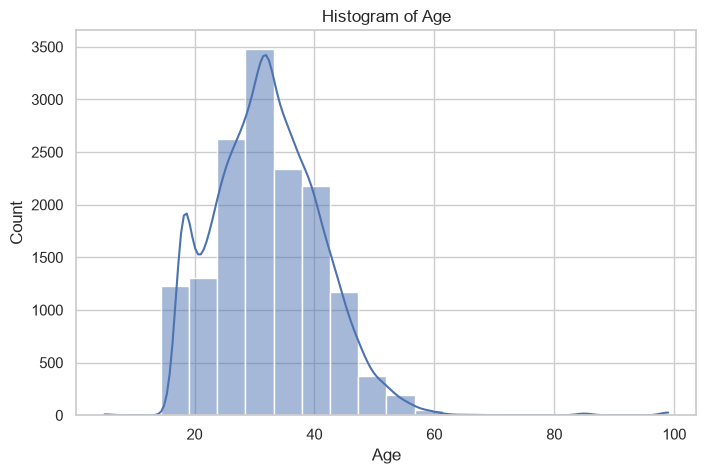

In [59]:
if "Age" in clean_df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=clean_df, x="Age", bins=20, kde=True, color="C0")
    plt.title("Histogram of Age")
    plt.show()

### Observation — Age
Customer ages are concentrated around the late 20s to late 30s. The mean age is **32.30 years** and the median is **32 years**. The distribution has a small right tail because of unusually high ages, including values up to 99.

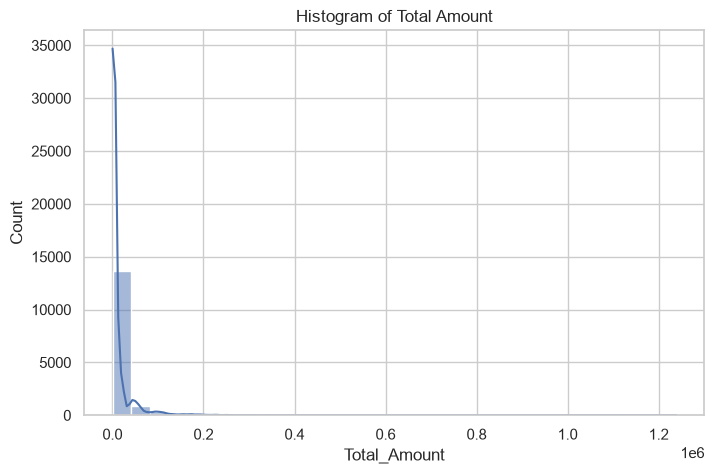

In [60]:
if "Total_Amount" in clean_df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=clean_df, x="Total_Amount", bins=30, kde=True, color="C0")
    plt.title("Histogram of Total Amount")
    plt.show()

### Observation — Total Amount
Most order values are concentrated at relatively lower amounts, with a strong right-skewed tail. The median order value is about **₹3,223.75**, while the mean is about **₹12,565.93** after cleaning. A relatively small number of very high-value orders substantially increase the mean.

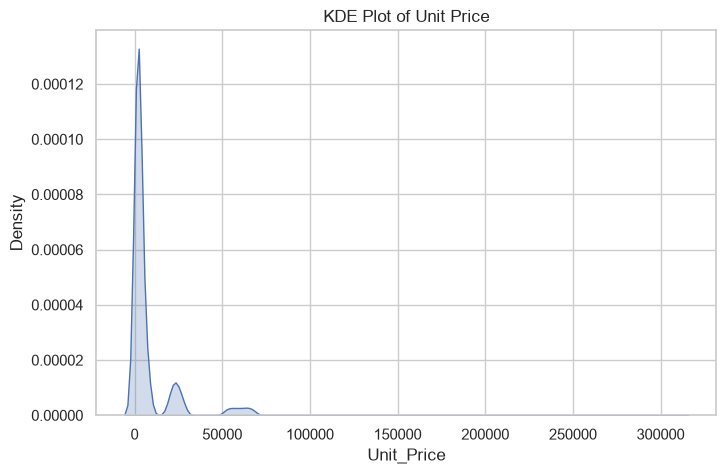

In [61]:
if "Unit_Price" in clean_df.columns:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=clean_df, x="Unit_Price", fill=True, color="C0")
    plt.title("KDE Plot of Unit Price")
    plt.show()

### Observation — Unit Price
The KDE shows that most unit prices are concentrated at comparatively lower values, while a long right tail extends to very high prices. The mean unit price (**₹7,417.83**) is much higher than the median (**₹2,480.28**), confirming strong positive skewness.

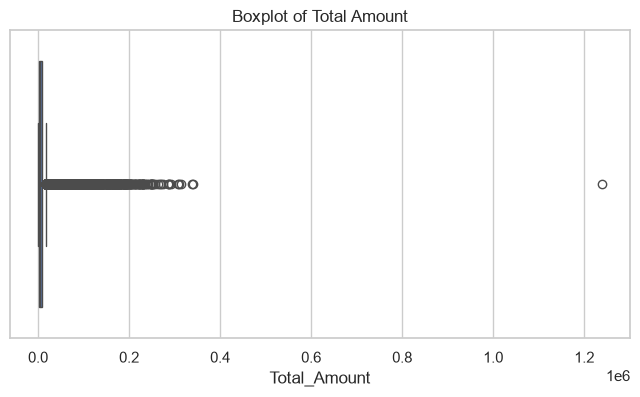

In [62]:
if "Total_Amount" in clean_df.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=clean_df, x="Total_Amount", color="C0")
    plt.title("Boxplot of Total Amount")
    plt.show()

### Observation — Total Amount Boxplot
The Total_Amount boxplot shows a relatively compact central range with many high-value observations beyond the upper whisker. This confirms that order values contain substantial extreme variation, including very large legitimate-looking transactions.

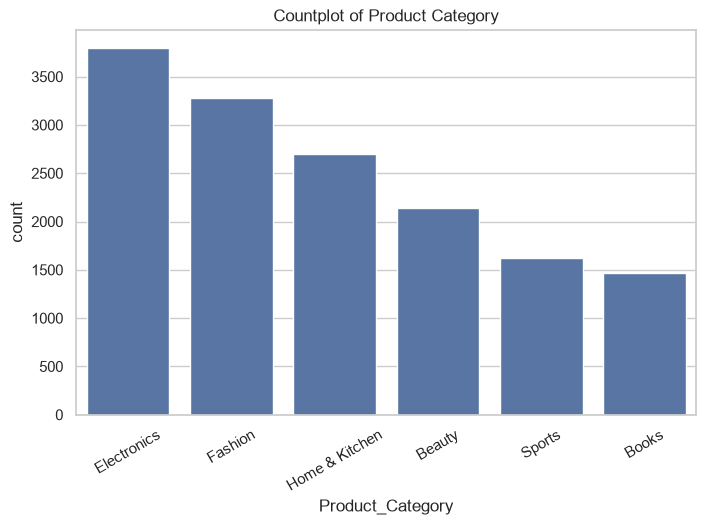

In [63]:
if "Product_Category" in clean_df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=clean_df, x="Product_Category", order=clean_df["Product_Category"].value_counts().index, color="C0")
    plt.title("Countplot of Product Category")
    plt.xticks(rotation=30)
    plt.show()

### Observation — Countplot of Product Category
**Electronics** is the most frequently ordered category with **3,796 orders**, followed by Fashion (3,278). **Books** has the fewest orders with **1,466**. This indicates that electronics has the strongest order-volume presence in the dataset.

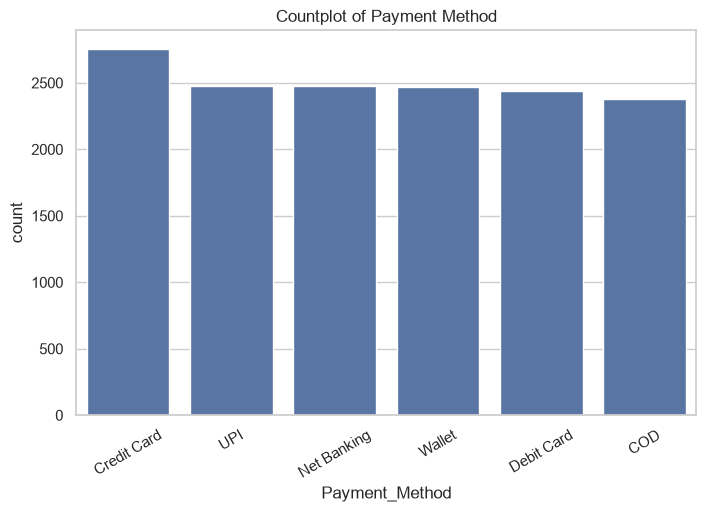

In [64]:
if "Payment_Method" in clean_df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=clean_df, x="Payment_Method", order=clean_df["Payment_Method"].value_counts().index, color="C0")
    plt.title("Countplot of Payment Method")
    plt.xticks(rotation=30)
    plt.show()

### Observation — Countplot of Payment Method
**Credit Card** is the most popular payment method with **2,758 orders**. COD is the least frequent with **2,379 orders**. The other four methods are relatively close in frequency, indicating a diversified payment mix.

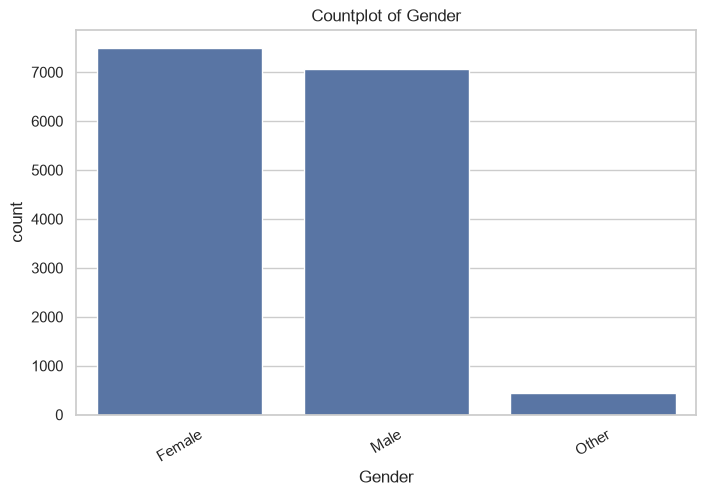

In [65]:
if "Gender" in clean_df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=clean_df, x="Gender", order=clean_df["Gender"].value_counts().index, color="C0")
    plt.title("Countplot of Gender")
    plt.xticks(rotation=30)
    plt.show()

### Observation — Countplot of Gender
After cleaning, **Female** is the largest gender group with **7,494 records**, followed by Male and Other. The distribution is reasonably balanced between Male and Female, while Other represents a much smaller group.

# Task 16: Seaborn Bivariate Analysis

### Summary
Study relationships between two variables using scatterplots, barplots, boxplots, or violinplots as appropriate.

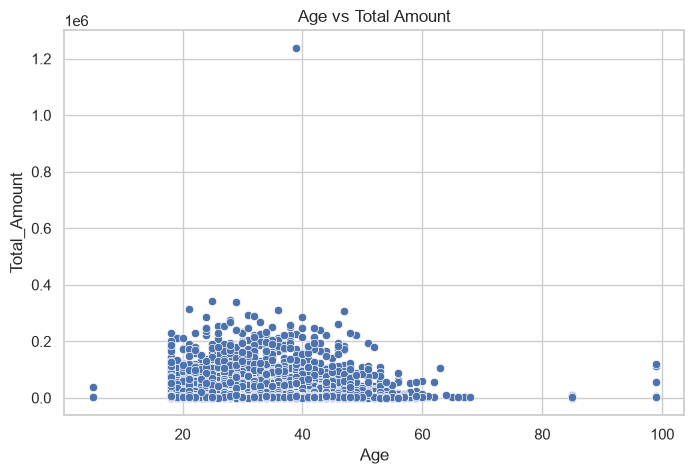

In [66]:
if all(c in clean_df.columns for c in ["Age", "Total_Amount"]):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=clean_df, x="Age", y="Total_Amount", color="C0")
    plt.title("Age vs Total Amount")
    plt.show()

### Interpretation — Age vs Total Amount
The scatterplot shows a very weak linear relationship between Age and Total_Amount. The correlation is approximately **−0.004**, meaning age alone provides almost no linear explanation for differences in order value in this dataset.

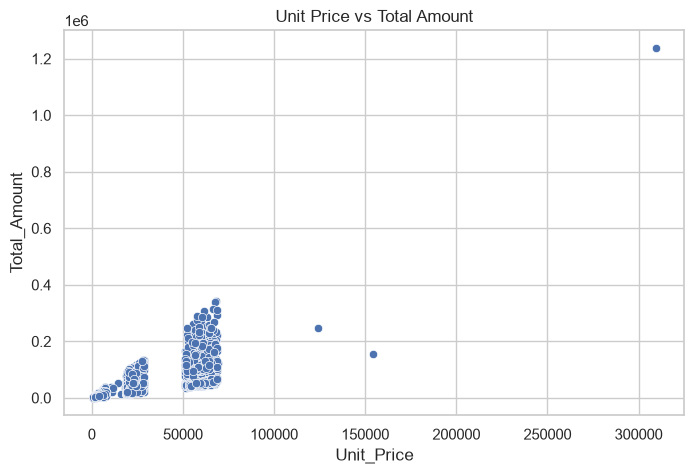

In [67]:
if all(c in clean_df.columns for c in ["Unit_Price", "Total_Amount"]):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=clean_df, x="Unit_Price", y="Total_Amount", color="C0")
    plt.title("Unit Price vs Total Amount")
    plt.show()

### Interpretation — Unit Price vs Total Amount
Unit_Price has a strong positive relationship with Total_Amount. The correlation is approximately **0.835**, so higher-priced items are generally associated with higher order totals. This is expected because unit price is directly involved in the order-total calculation.

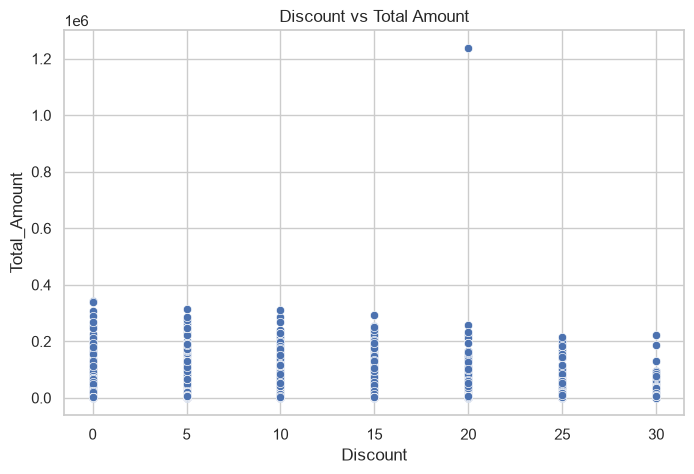

In [68]:
if all(c in clean_df.columns for c in ["Discount", "Total_Amount"]):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=clean_df, x="Discount", y="Total_Amount", color="C0")
    plt.title("Discount vs Total Amount")
    plt.show()

### Interpretation — Discount vs Total Amount
Discount has a very weak negative relationship with Total_Amount, with a correlation of approximately **−0.041**. Therefore, discount percentage by itself does not appear to be an important linear driver of total order value in this dataset.

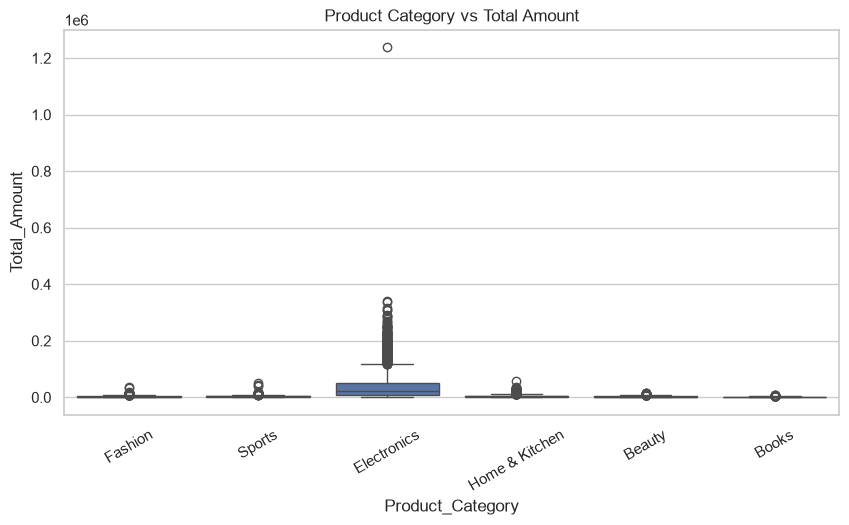

In [69]:
if all(c in clean_df.columns for c in ["Product_Category", "Total_Amount"]):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=clean_df, x="Product_Category", y="Total_Amount", color="C0")
    plt.title("Product Category vs Total Amount")
    plt.xticks(rotation=30)
    plt.show()

### Interpretation — Product Category vs Total Amount
Electronics has by far the highest typical and average order values, while Books has the lowest. The Electronics average is unusually high because the category contains several very large-value transactions, so both the median and extreme values should be considered when interpreting category performance.

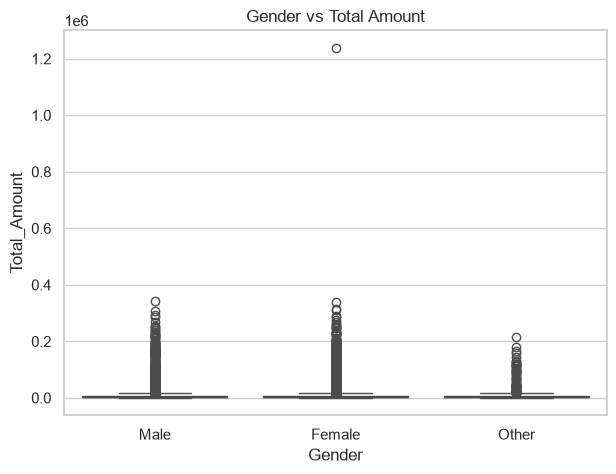

In [70]:
if all(c in clean_df.columns for c in ["Gender", "Total_Amount"]):
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=clean_df, x="Gender", y="Total_Amount", color="C0")
    plt.title("Gender vs Total Amount")
    plt.show()

### Interpretation — Gender vs Total Amount
The gender boxplot shows substantial overlap among groups. The **Other** group has the highest average spending, followed by Female and Male, but the group sizes are very different. Therefore, average differences should be interpreted cautiously rather than treated as evidence that gender causes higher spending.

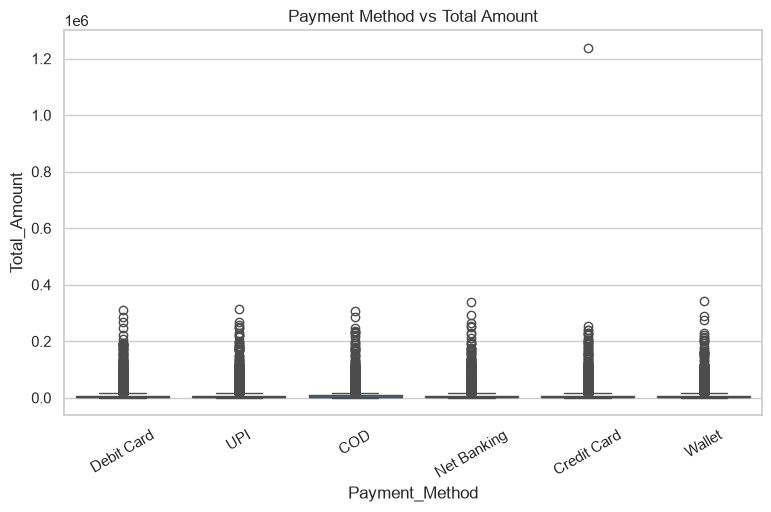

In [71]:
if all(c in clean_df.columns for c in ["Payment_Method", "Total_Amount"]):
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=clean_df, x="Payment_Method", y="Total_Amount", color="C0")
    plt.title("Payment Method vs Total Amount")
    plt.xticks(rotation=30)
    plt.show()

### Interpretation — Payment Method vs Total Amount
Order-value distributions overlap considerably across payment methods. Differences in typical spending are smaller than the effect of Unit_Price, indicating that payment method is not one of the strongest numerical predictors of Total_Amount.

# Task 17: Multivariate Analysis

### Summary
Use a pairplot for selected numerical variables, a correlation heatmap, and categorical comparisons using `hue`.

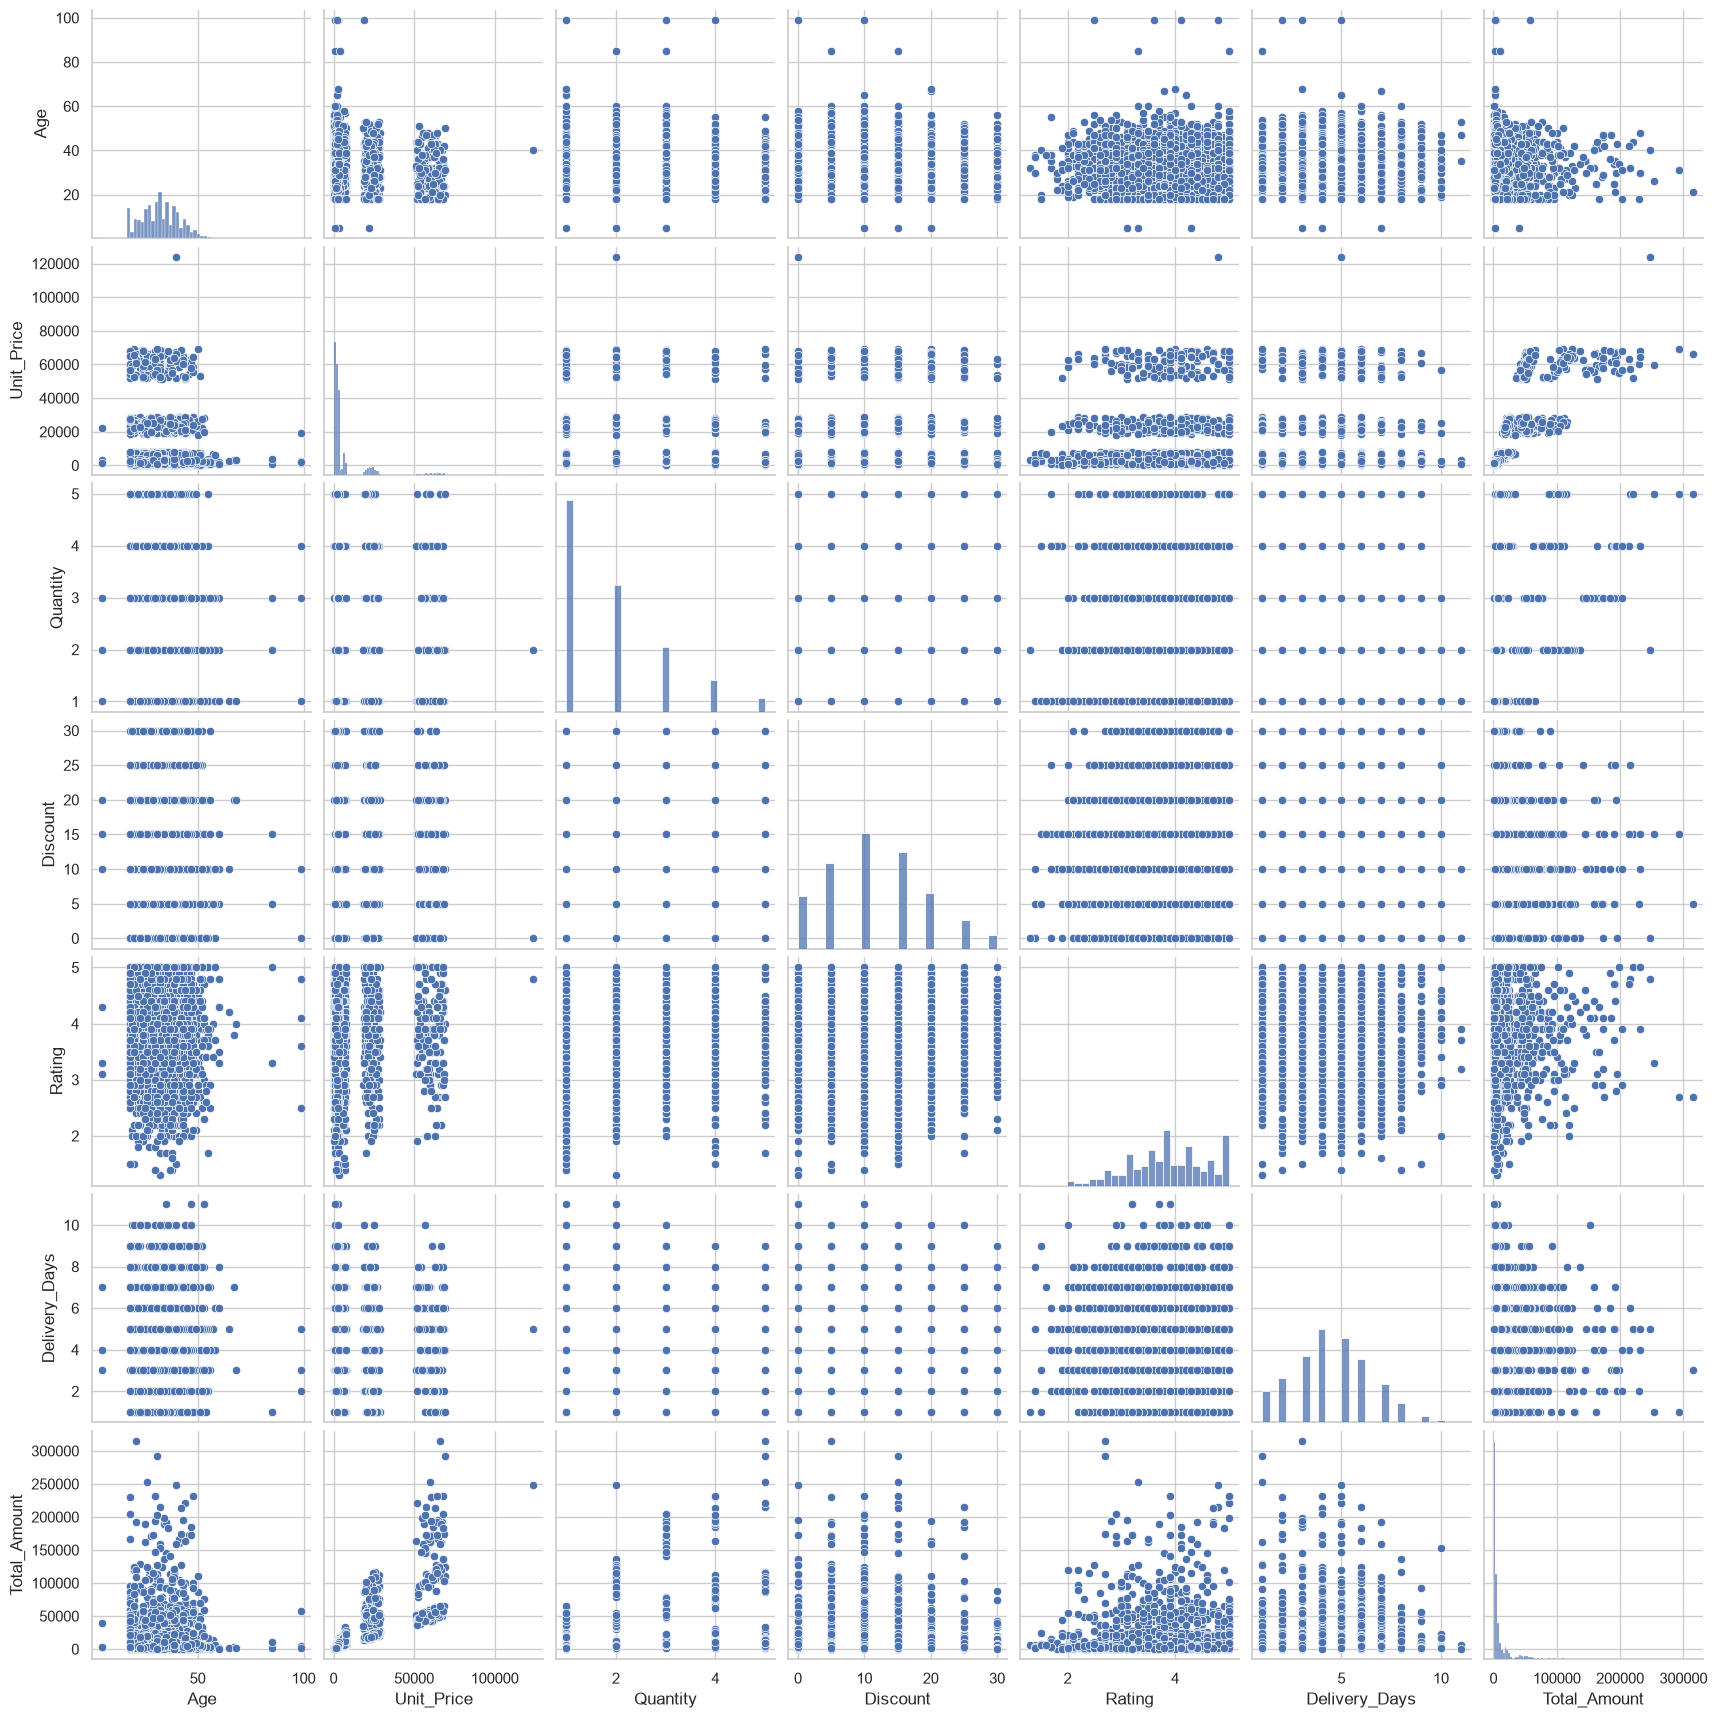

In [72]:
pair_cols = [c for c in [
    "Age", "Unit_Price", "Quantity", "Discount",
    "Rating", "Delivery_Days", "Total_Amount"
] if c in clean_df.columns]

# Limit the number of rows used in the pairplot for faster rendering if the dataset is large.
pair_sample = clean_df[pair_cols].sample(min(3000, len(clean_df)), random_state=42)

sns.pairplot(pair_sample, plot_kws={"color": "C0"}, diag_kws={"color": "C0"})
plt.show()

### Interpretation — Pairplot
The pairplot confirms the main relationships seen in the individual analyses. The clearest positive pattern is between **Unit_Price and Total_Amount**. Quantity has a weaker positive association with Total_Amount, while Age, Discount, Rating, and Delivery_Days show little linear association with order value.

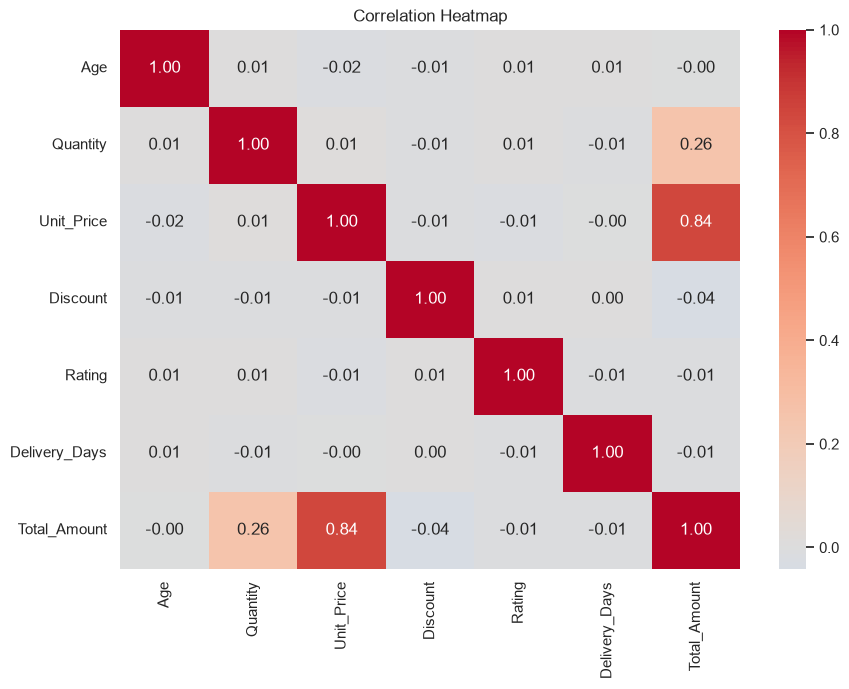

In [73]:
corr_cols = clean_df.select_dtypes(include=np.number).columns
corr_matrix = clean_df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### Interpretation — Correlation Heatmap
The heatmap shows the strongest positive relationship between **Unit_Price and Total_Amount (about 0.84)**. Quantity has a moderate positive relationship with Total_Amount (about 0.26). Age, Discount, Rating, and Delivery_Days are close to zero in correlation with Total_Amount, indicating weak linear relationships.

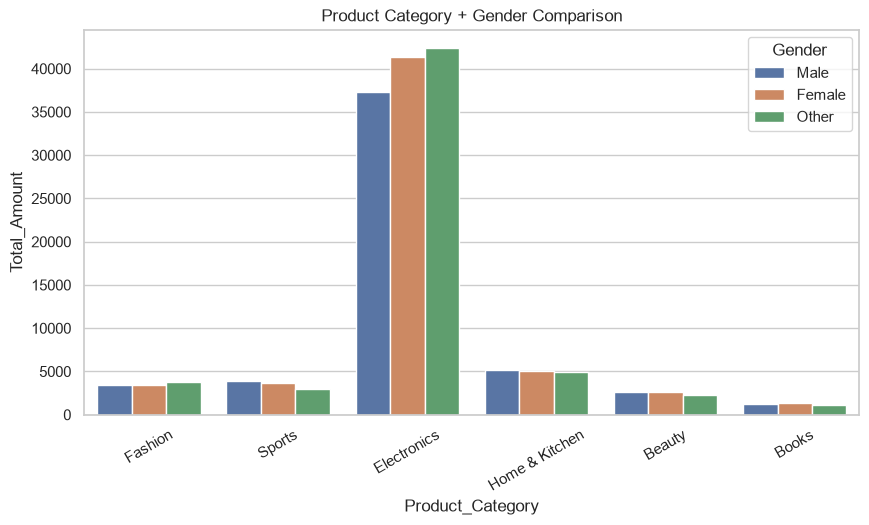

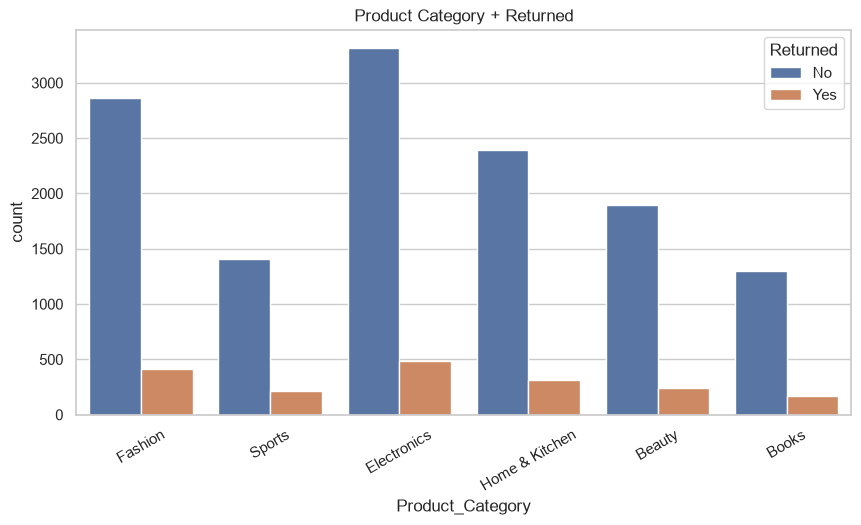

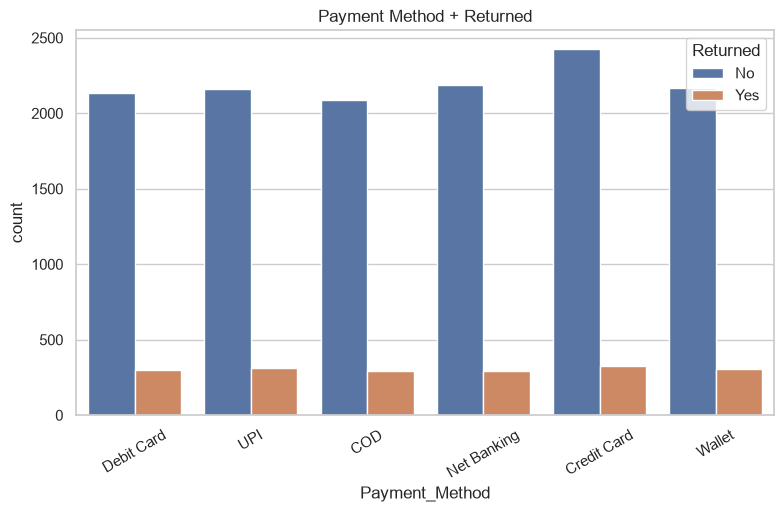

In [74]:
if all(c in clean_df.columns for c in ["Product_Category", "Gender", "Total_Amount"]):
    plt.figure(figsize=(10, 5))
    sns.barplot(data=clean_df, x="Product_Category", y="Total_Amount", hue="Gender", errorbar=None)
    plt.title("Product Category + Gender Comparison")
    plt.xticks(rotation=30)
    plt.show()

if all(c in clean_df.columns for c in ["Product_Category", "Returned"]):
    plt.figure(figsize=(10, 5))
    sns.countplot(data=clean_df, x="Product_Category", hue="Returned")
    plt.title("Product Category + Returned")
    plt.xticks(rotation=30)
    plt.show()

if all(c in clean_df.columns for c in ["Payment_Method", "Returned"]):
    plt.figure(figsize=(9, 5))
    sns.countplot(data=clean_df, x="Payment_Method", hue="Returned")
    plt.title("Payment Method + Returned")
    plt.xticks(rotation=30)
    plt.show()

### Interpretation — Categorical Comparisons
The hue-based comparisons show how order counts and returns vary across product categories, gender, and payment methods. Electronics has the largest order volume, while returns remain a minority across categories. These categorical differences are useful for descriptive business analysis but do not by themselves establish causal relationships.

# Task 18: Correlation Analysis

### Summary
Create a correlation matrix and identify the strongest positive correlation, strongest negative correlation, weak correlations, and variables that may be useful for predicting `Total_Amount`.

In [75]:
corr = clean_df.select_dtypes(include=np.number).corr()

display(corr)

if "Total_Amount" in corr.columns:
    total_corr = corr["Total_Amount"].drop("Total_Amount").sort_values(ascending=False)
    print("Correlations with Total_Amount:")
    display(total_corr)

    print("Strongest positive correlation with Total_Amount:")
    print(total_corr.idxmax(), total_corr.max())

    print("Strongest negative correlation with Total_Amount:")
    print(total_corr.idxmin(), total_corr.min())

    print("Weakest absolute correlations with Total_Amount:")
    display(total_corr.reindex(total_corr.abs().sort_values().index).head())

,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
Age,1.000000,0.011426,-0.016544,-0.009784,0.005734,0.006673,-0.004330
Quantity,0.011426,1.000000,0.012130,-0.005515,0.007088,-0.009716,0.255942
Unit_Price,-0.016544,0.012130,1.000000,-0.005659,-0.014778,-0.000417,0.835066
Discount,-0.009784,-0.005515,-0.005659,1.000000,0.007764,0.004916,-0.041234
Rating,0.005734,0.007088,-0.014778,0.007764,1.000000,-0.007873,-0.008006
Delivery_Days,0.006673,-0.009716,-0.000417,0.004916,-0.007873,1.000000,-0.007124
Total_Amount,-0.004330,0.255942,0.835066,-0.041234,-0.008006,-0.007124,1.000000


Correlations with Total_Amount:


Unit_Price       0.835066
Quantity         0.255942
Age             -0.004330
Delivery_Days   -0.007124
Rating          -0.008006
Discount        -0.041234
Name: Total_Amount, dtype: float64

Strongest positive correlation with Total_Amount:
Unit_Price 0.8350661199581896
Strongest negative correlation with Total_Amount:
Discount -0.0412337856257941
Weakest absolute correlations with Total_Amount:


Age             -0.004330
Delivery_Days   -0.007124
Rating          -0.008006
Discount        -0.041234
Quantity         0.255942
Name: Total_Amount, dtype: float64

### Interpretation
The strongest numerical relationship with Total_Amount is **Unit_Price (r ≈ 0.835)**, followed by **Quantity (r ≈ 0.256)**. Discount, Rating, Delivery_Days, and Age have correlations close to zero. Therefore, Unit_Price and Quantity appear most useful for explaining Total_Amount among the available numerical features, although correlation alone does not prove causation.

# Task 19: Business Insights

### Summary
Use the cleaned dataset to answer the business questions in the assignment: most ordered category, highest average order value, popular payment method, highest-sales city, gender spending, discount effect, ratings, return percentage, delivery time and ratings, and factors influencing Total Amount.

In [76]:
# Business insights calculated from the cleaned dataset.

category_counts = clean_df["Product_Category"].value_counts()
avg_category = clean_df.groupby("Product_Category")["Total_Amount"].mean().sort_values(ascending=False)
payment_counts = clean_df["Payment_Method"].value_counts()
city_sales = clean_df.groupby("City")["Total_Amount"].sum().sort_values(ascending=False)
gender_avg = clean_df.groupby("Gender")["Total_Amount"].mean().sort_values(ascending=False)
rating_category = clean_df.groupby("Product_Category")["Rating"].mean().sort_values(ascending=False)
return_pct = clean_df["Returned"].value_counts(normalize=True) * 100
discount_corr = clean_df[["Discount", "Total_Amount"]].corr().iloc[0, 1]
delivery_rating_corr = clean_df[["Delivery_Days", "Rating"]].corr().iloc[0, 1]
total_corr = clean_df.select_dtypes(include=np.number).corr()["Total_Amount"].drop("Total_Amount").sort_values(ascending=False)

print("1. Most ordered product category:", category_counts.idxmax(), "(", int(category_counts.max()), "orders )")
print("2. Highest average order value:", avg_category.index[0], "₹", round(avg_category.iloc[0], 2))
print("3. Most popular payment method:", payment_counts.idxmax(), "(", int(payment_counts.max()), "orders )")
print("4. City with highest sales:", city_sales.index[0], "₹", round(city_sales.iloc[0], 2))
print("5. Gender with highest average spending:", gender_avg.index[0], "₹", round(gender_avg.iloc[0], 2))
print("6. Discount vs Total Amount correlation:", round(discount_corr, 4))
print("7. Highest average rating category:", rating_category.index[0], round(rating_category.iloc[0], 2))
print("8. Return percentage:")
display(return_pct.rename("Percentage").to_frame())
print("9. Delivery Days vs Rating correlation:", round(delivery_rating_corr, 4))
print("10. Correlations with Total Amount:")
display(total_corr.to_frame("Correlation"))

1. Most ordered product category: Electronics ( 3796 orders )
2. Highest average order value: Electronics ₹ 39440.44
3. Most popular payment method: Credit Card ( 2758 orders )
4. City with highest sales: Kolkata ₹ 17425135.1
5. Gender with highest average spending: Other ₹ 13962.82
6. Discount vs Total Amount correlation: -0.0412
7. Highest average rating category: Beauty 3.91
8. Return percentage:


,Percentage
Returned,
No,87.793333
Yes,12.206667


9. Delivery Days vs Rating correlation: -0.0079
10. Correlations with Total Amount:


,Correlation
Unit_Price,0.835066
Quantity,0.255942
Age,-0.004330
Delivery_Days,-0.007124
Rating,-0.008006
Discount,-0.041234


### Business Insights — Interpretation
1. **Most ordered category:** Electronics leads with **3,796 orders**.
2. **Highest average order value:** Electronics has the highest average Total_Amount at about **₹39,440**, much higher than the other categories.
3. **Most popular payment method:** Credit Card leads with **2,758 orders**.
4. **Highest-sales city:** Kolkata has the highest total sales at approximately **₹17.43 million**.
5. **Gender spending:** The Other group has the highest average spending, followed by Female and Male; the smaller Other group means this result should be interpreted cautiously.
6. **Discount effect:** Discount and Total_Amount have a very weak negative correlation of about **−0.041**, so no strong linear relationship is evident.
7. **Highest-rated category:** Beauty has the highest average rating at about **3.91**.
8. **Return rate:** About **12.21%** of orders are returned, while **87.79%** are not returned.
9. **Delivery and ratings:** Delivery_Days and Rating have an almost zero correlation (about **−0.008**), so delivery time does not show a meaningful linear relationship with ratings.
10. **Main Total_Amount drivers:** Unit_Price is the strongest numerical correlate (about **0.835**), followed by Quantity (about **0.256**).

# Task 20: Final Conclusion

### Conclusion
The E-Commerce dataset was successfully inspected, cleaned, validated, and analyzed. Missing values were handled using median imputation for numerical variables and mode imputation for categorical variables. Capitalization inconsistencies were standardized, and **75 exact duplicate rows were removed**, producing a final dataset of **15,000 records**.

The exploratory analysis shows strong right-skewness in `Unit_Price` and `Total_Amount`, with several high-value observations. These outliers were retained because the available information did not justify classifying them as errors. The consistency check showed that the expected order amount generally agrees closely with `Total_Amount`, although a small number of records have larger differences that may require further investigation.

The visual and correlation analyses indicate that **Unit_Price is the strongest numerical feature associated with Total_Amount**, followed by Quantity. Electronics has the highest order volume and the highest average order value, Credit Card is the most common payment method, and approximately 12.21% of orders are returned.

Overall, the cleaned dataset is suitable for exploratory data analysis and descriptive business insights. Further predictive analysis could investigate high-value orders and the reasons behind the pricing inconsistencies identified during validation.

# Final Submission Checklist

According to the assignment, submit:

- `Ecommerce_EDA_StudentName.ipynb`
- `cleaned_ecommerce_dataset.csv`
- Short report containing:
  - Dataset description
  - Data-quality problems identified
  - Cleaning techniques used
  - Visualizations
  - Important observations
  - Business insights
  - Final conclusion

### Important
Every output and visualization should be followed by an interpretation in your own words.